In [1]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
lag = 20
n_steps_out = 1
data = dataloader(path=path, supervised=True, lag=lag, n_steps_out=n_steps_out)

2024-04-18 08:37:55.980 | INFO     | utils.DataPreprocessing:load_csv:132 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-18 08:37:55.981 | INFO     | utils.DataPreprocessing:load_csv:134 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


2024-04-18 08:37:56.163 | INFO     | utils.DataPreprocessing:feature_engineering:298 - shape: (8_523, 16)
┌───────────┬───────────────┬───────────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ date          ┆ GSR       ┆ SUN  ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---           ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---     │
│ f32       ┆ datetime[μs]  ┆ f32       ┆ f32  ┆   ┆ i8         ┆ i8         ┆ i16       ┆ i8      │
╞═══════════╪═══════════════╪═══════════╪══════╪═══╪════════════╪════════════╪═══════════╪═════════╡
│ 29.200001 ┆ 1999-08-01    ┆ 25.1      ┆ 11.6 ┆ … ┆ 1          ┆ 30         ┆ 213       ┆ 3       │
│           ┆ 00:00:00      ┆           ┆      ┆   ┆            ┆            ┆           ┆         │
│ 29.1      ┆ 1999-08-02    ┆ 15.13     ┆ 7.0  ┆ … ┆ 2          ┆ 31         ┆ 214       ┆ 3       │
│           ┆ 00:00:00      ┆           ┆      ┆   ┆            ┆            ┆        

In [2]:
logger.success(data.X_train)
logger.success(data.y_train)
logger.success(data.X_test)
logger.success(data.y_test)

2024-04-18 08:37:56.210 | SUCCESS  | __main__:<module>:1 - shape: (6_801, 34)
┌───────────┬──────┬──────┬─────┬───┬──────────────┬──────────────┬──────────────┬──────────────┐
│ GSR       ┆ SUN  ┆ RH   ┆ UV  ┆ … ┆ AVG_TEMP_t-4 ┆ AVG_TEMP_t-3 ┆ AVG_TEMP_t-2 ┆ AVG_TEMP_t-1 │
│ ---       ┆ ---  ┆ ---  ┆ --- ┆   ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ f32       ┆ f32  ┆ f32  ┆ f32 ┆   ┆ f32          ┆ f32          ┆ f32          ┆ f32          │
╞═══════════╪══════╪══════╪═════╪═══╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 16.440001 ┆ 6.9  ┆ 75.0 ┆ 4.0 ┆ … ┆ 28.799999    ┆ 29.0         ┆ 29.299999    ┆ 30.299999    │
│ 1.93      ┆ 0.0  ┆ 79.0 ┆ 0.6 ┆ … ┆ 29.0         ┆ 29.299999    ┆ 30.299999    ┆ 29.299999    │
│ 3.04      ┆ 0.0  ┆ 92.0 ┆ 1.0 ┆ … ┆ 29.299999    ┆ 30.299999    ┆ 29.299999    ┆ 25.9         │
│ 4.34      ┆ 0.0  ┆ 91.0 ┆ 1.0 ┆ … ┆ 30.299999    ┆ 29.299999    ┆ 25.9         ┆ 24.1         │
│ 2.04      ┆ 0.0  ┆ 93.0 ┆ 0.5 ┆ … ┆ 29

In [3]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

reg = xgb.XGBRegressor(base_score=0.5, 
                       booster='gbtree',    
                     # n_estimators=1000,
                     # early_stopping_rounds=50,
                     objective='reg:squarederror',
                     # max_depth=3,
                     # learning_rate=0.01, 
                     tree_method = "hist", 
                     device = "cuda")

# set up our search grid
param_grid = {"max_depth": list(range(3, 5, 1)), # 4
              "n_estimators": list(range(700, 1000, 100)), # 900
              "learning_rate": [0.015, 0.02, 0.025], # 0.02
              "min_child_weight": [5, 7, 9], # 5
              }

# search = GridSearchCV(reg, param_grid, cv=5, verbose=100).fit(x_train, y_train)

# print("The best hyperparameters are ",search.best_params_)

In [4]:
# reg:xgb.XGBRegressor=xgb.XGBRegressor(learning_rate = search.best_params_["learning_rate"],
#                                    n_estimators = search.best_params_["n_estimators"],
#                                    max_depth = search.best_params_["max_depth"],
#                                    early_stopping_rounds=50,
#                                    objective='reg:squarederror',
#                                    base_score=0.5,
#                                    booster='gbtree',)

reg: xgb.sklearn.XGBRegressor = xgb.sklearn.XGBRegressor(
    learning_rate=0.02,
    n_estimators=900,
    max_depth=4,
    # early_stopping_rounds=50,
    objective="reg:squarederror",
    base_score=0.5,
    min_child_weight=5,
    booster="gbtree",
    tree_method="hist",
    device="cuda",
)

from sklearn.multioutput import MultiOutputRegressor

# Create a multi-output regressor
multioutput_reg = MultiOutputRegressor(reg)

In [5]:
# from skforecast.ForecasterAutoreg import ForecasterAutoreg
# import pandas as pd
# lag = 3
# forecaster = ForecasterAutoreg(regressor=reg, 
#                                      lags=lag)

# print(data.y_train.to_pandas())
# forecaster.fit(y=data.y_train.to_pandas())

# predictions = forecaster.predict(steps=5)

In [6]:
# reg.fit(data.X_train, data.y_train,
#         eval_set=[(data.X_train, data.y_train), (data.X_test, data.y_test)],
#         verbose=100)

# Fit the multi-output regressor to the data
multioutput_reg.fit(
    X=data.X_train,
    y=data.y_train,
    verbose=100,
    # eval_set=[(data.X_test, data.y_test)]
)

MultiOutputRegressor(estimator=XGBRegressor(base_score=0.5, booster='gbtree',
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            device='cuda',
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.02, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=4,
                                            max_leaves=None, min_child_weight=5,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=900, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...))

In [7]:
# import matplotlib.pyplot as plt
# from sklearn.metrics import r2_score
# # plot the loss
# results = multioutput_reg.evals_result()
# epochs = len(results['validation_0']['rmse'])
# x_axis = range(0, epochs)
# fig, ax = plt.subplots(figsize=(15, 5))
# ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
# ax.plot(x_axis, results['validation_1']['rmse'], label='Test')
# ax.legend()
# plt.ylabel('RMSE')
# plt.title('XGBoost RMSE')
# plt.savefig('loss.png')

In [8]:
# Predict the values
y_train_pred = multioutput_reg.predict(data.X_train)
y_test_pred = multioutput_reg.predict(data.X_test)

# # Plot R^2 scores
# plt.figure(figsize=(10, 6))
# plt.bar(['Train', 'Test'], [r2_train, r2_test])
# plt.title('R^2 Scores for Train and Test Sets')
# plt.ylabel('R^2 Score')
# plt.show()


In [9]:
# cal the r2 score, mse, mae
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# r2_score_train = r2_score(data.y_train, y_train_pred)
r2_score_test = r2_score(data.y_test, y_test_pred)
mse_test = mean_squared_error(data.y_test, y_test_pred)
mae_test = mean_absolute_error(data.y_test, y_test_pred)

logger.success(f"R2 score for test set: {r2_score_test}")
logger.success(f"MSE for test set: {mse_test}")
logger.success(f"MAE for test set: {mae_test}")


2024-04-18 08:38:04.950 | SUCCESS  | __main__:<module>:10 - R2 score for test set: 0.9290513019595568
2024-04-18 08:38:04.952 | SUCCESS  | __main__:<module>:11 - MSE for test set: 1.564351201057434
2024-04-18 08:38:04.954 | SUCCESS  | __main__:<module>:12 - MAE for test set: 0.8917579054832458


In [10]:
logger.success(y_test_pred)

2024-04-18 08:38:04.967 | SUCCESS  | __main__:<module>:1 - [[25.266512 25.40811 ]
 [25.33921  25.553553]
 [23.327219 22.348988]
 ...
 [21.160805 21.47838 ]
 [23.21454  22.172354]
 [25.543068 24.265121]]


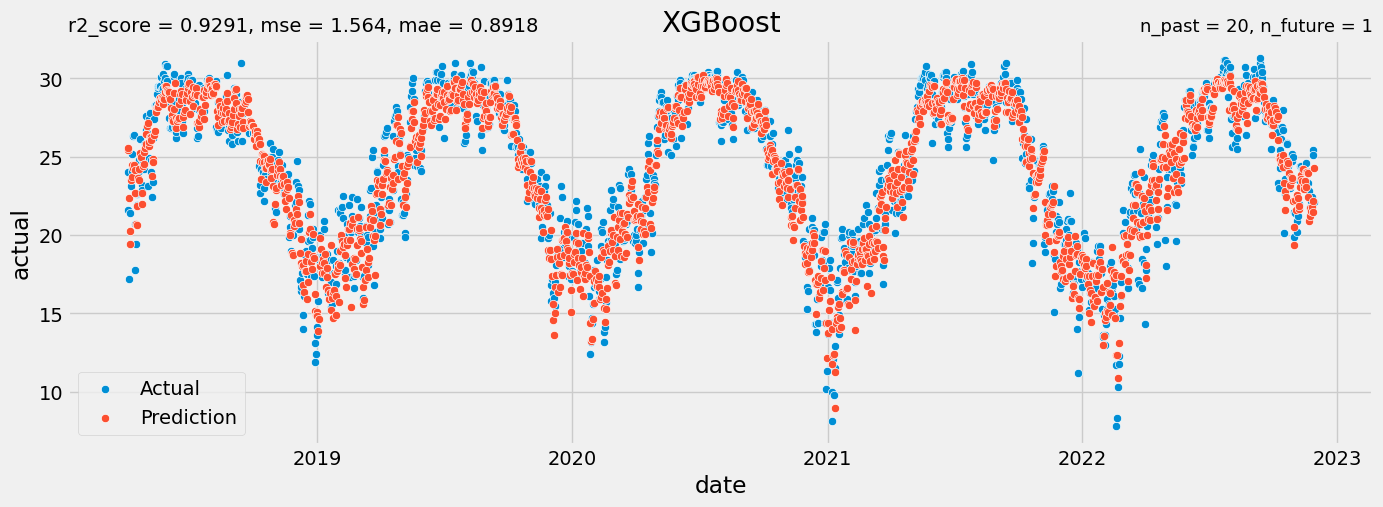

In [11]:
from polars import DataFrame
import seaborn as sns
import matplotlib.pyplot as plt

def plot_predictions(testing_dates, y_test, prediction):
    fig, ax = plt.subplots(
        figsize=(15, 5),
    )
    df_test = DataFrame(
        {"date": testing_dates, "actual": y_test, "prediction": prediction}
    )
    date_col = "date"
    data_col = df_test.columns[1]  # Assuming the first column is 'date'
    plot_data = df_test[[date_col, data_col]]
    sns.scatterplot(x=date_col, y=data_col, data=plot_data)

    data_col = df_test.columns[2]
    plot_data = df_test[[date_col, data_col]]
    sns.scatterplot(x=date_col, y=data_col, data=plot_data)
    plt.title("XGBoost")
    plt.title(f"n_past = {lag:}, n_future = {n_steps_out}", loc="right", fontsize=13)
    plt.title(f"r2_score = {r2_score_test:.4}, mse = {mse_test:.4}, mae = {mae_test:.4}", loc="left", fontsize=14)
    plt.legend(["Actual", "Prediction"])
    plt.savefig("xgboost.png")
  
plot_predictions(data.date_test, data.y_test[:, -1], y_test_pred[:,-1])
# plot_predictions(x_test.index[-10:], y_test[-10:], y_test_pred[-10:])